## 1. 시계열 데이터란?

### 1.1 시계열 데이터의 정의
- **순차적인 시간 흐름**에 따라 수집된 데이터
- 연속한 관측치는 서로 **상관관계**가 존재하며, 순서가 중요한 **시퀀스 데이터**
- **단변량 시계열**: 하나의 변수가 시간에 따라 변화 (예: 주식 가격)
- **다변량 시계열**: 둘 이상의 변수가 동시에 시간에 따라 변화 (예: 경제 지표)

### 1.2 시계열 데이터의 특성
| 특성 | 설명 |
|------|------|
| **시간의존성** | 데이터의 순서를 바꾸면 의미가 달라짐, 과거 값이 현재에 영향 |
| **계절성 & 추세** | 일정 주기로 반복되는 패턴 + 장기적 증가/감소 경향 |
| **자기상관성** | 이전 시점의 값이 이후 시점의 값에 영향 → 일반 회귀분석 부적합 |

### 1.3 시계열 데이터의 분석요인
>  **추세 요인 (Trend)**: 시간에 따른 지속적 증가/감소 경향

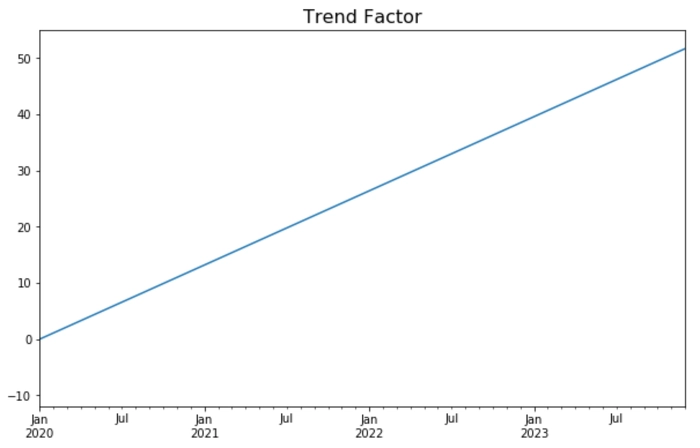
> **계절 요인 (Seasonal)**: 일정 주기(월, 분기 등)로 반복되는 패턴

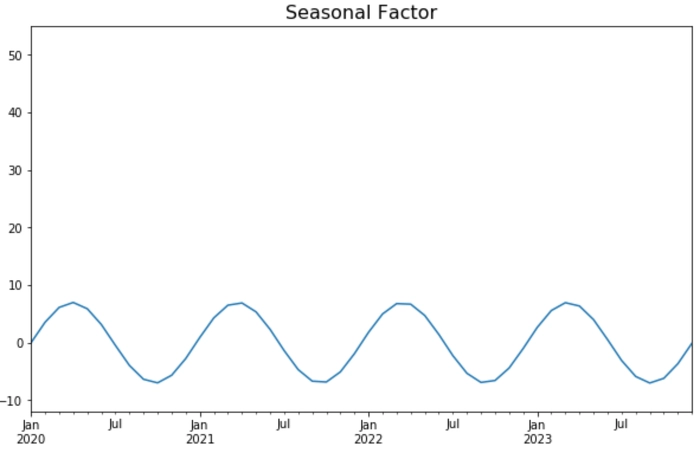
>  **순환 요인 (Cycle)**: 계절성보다 길고 불규칙한 주기의 변동 (경기 순환 등)

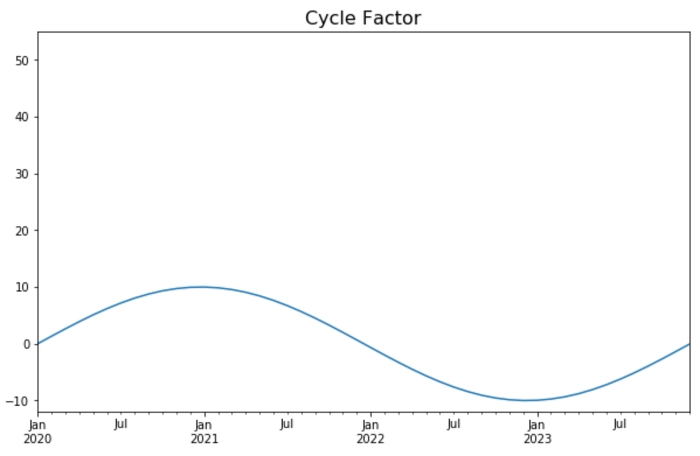
>  **불규칙 요인 (Irregular)**: 예측 불가능한 노이즈, 우연적 사건


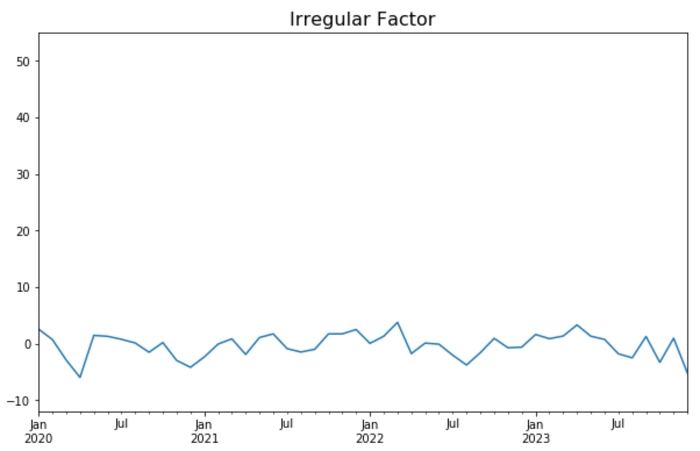
---


## 2. 시계열 데이터 전처리

### 시계열 데이터의 결측치

- 특정 시점(time point)에서 값이 측정되지 않았거나 **누락된 상태**
- 센서 오류·수집 누락·전송 지연 등으로 발생
- 결측치가 존재하면 **추세·계절성이 왜곡**되므로 적절한 대치와 보간이 필요

### 시계열 데이터의 이상치

- 값이 측정되었으나, 측정된 값이 **일반적이지 않은 경우**
- 측정 오류이거나, 실제로 특이한 이벤트일 수도 있는 극단적인 값
- 단순히 이상한 값이 아니라 **신호의 중요한 의미**일 가능성도 있으므로 신중한 접근 필요

  - → 신호에 대한 **사전 지식** 필요

### 2.1 결측치/이상치 처리
**결측치 처리 방법**
- **삭제**: 시간 연속성이 깨질 수 있음
- **단순 대치**: 평균, 중앙값, 최빈값으로 채움
- **보간법**: 선형 보간, 다항식 보간, 스플라인 보간, Forward/Backward Fill

**이상치 탐지 방법**
- **IQR Rule**: $Q1 - 1.5 \times IQR$ ~ $Q3 + 1.5 \times IQR$ 범위 벗어나면 이상치
- **Z-score**: $|Z| \geq 3$이면 이상치
- **STL 분해**: 잔차가 임계값 초과 시 이상치

### 2.2 EDA (평활화)
- **이동평균(MA)**
  - 시계열의 부분집합으로 평균을 구하여 평활화 효과를 얻는 방법
  - 윈도우(평균을 구할 구간의 크기) 내의 평균을 구하는 방법

- 사용 목적
  - 노이즈 제거: 일시적인 급등/급락을 평탄화
  - 추세 파악: 상승/하강 흐름을 쉽게 식별
  - 예측의 기초자료: 시계열 예측(ARIMA 등)의 기반이 되기도 함

- 이동평균의 유형
  - **단순 이동평균(SMA)**: 단순 평균
  - **가중 이동평균(WMA)**: 최근 값에 더 큰 가중치
  - **지수 이동평균(EMA)**: 지수적으로 감소하는 가중치 적용

### 2.3 요소분해 (Decomposition)
**분해 모형**
- **가법모형**: $y_t = T_t + S_t + R_t$ (변동폭 일정할 때)
  - 시계열 = 추세 + 계절성 + 불규칙성
  - 시계열 관측값은 변동요인들의 가법(+)으로 설명될 수 있다 가정
  - **각 변동 요인들이 독립적으로 더해지며, 모든 요소의 영향이 일정함**
  - 시계열 전체에서 계절성의 진폭이 일정할 때 적합
- **승법모형**: $y_t = T_t \times S_t \times R_t$ (변동폭이 추세에 비례할 때)
  * 로그 변환을 통해 가법 형태로 만들 수 있다
  - 시계열 = 추세 x 계절성 x 불규칙성
  - 시계열 관측값은 변동요인들의 승법(*)으로 설명될 수 있다 가정
  - **추세가 커질수록 계절성이나 불규칙성의 효과도 비례해서 커짐**
  - 진폭이 시간에 따라 달라질 때에 적합하다

**분해 방법**

- **seasonal_decompose** : 이동평균 기반, 고정된 계절성, 데이터 손실 발생
- **STL** : LOESS 기반, 변하는 계절성 반영, 이상치에 안정적

---


## 3. 정상성 판단

### 3.1 정상성의 정의
- **핵심**: 시간에 상관없이 통계적 특성(평균, 분산)이 일정

### 3.2 강한 정상성 vs 약한 정상성
> **강한 정상성**

- 개념: 시간을 언제로 잡든, 데이터의 확률 분포 자체가 똑같은 상태
- 특징: 평균, 분산 뿐만 아니라 데이터의 왜도, 첨도 등 모든 통계적 특성이 일정
- 한계: 현실의 데이터는 잡음과 외부 요인이 항상 존재하기 때문에, 이런 상태는 거의 존재하지 않음

> **약한 정상성**

- 평균이 일정: 시간이 지나도 일정한 수준을 유지
- 분산이 일정: 데이터의 오르내림 변동 폭이 일정한 수준을 유지
- 자기공분산이 시차에만 의존: 데이터 간의 관계가 특정 시점이 아니라 시간의 간격에 의해서만 결정
- **우리에게 필요한 데이터는 약한 정상성을 띄는 데이터**

### 3.3 정상성 판단 방법
**시각적 판단**: 일정한 기준선 중심으로 일정한 폭으로 진동하면 정상

- **비정상 시계열의 대표적인 특징**
    - 이런 모양이 존재하면 시각적으로 비정상 시계열임을 알 수 있음
    - 추세가 있는 경우: 시간에 따라 데이터가 지속적으로 상승하거나 하락(ex.주식 가격, 물가 상승률)
    - 계절성이 있는 경우: 1년 등의 특정 주기로 패턴이 반복됨 (ex. 월별 아이스크림 판매량)

**통계적 검정 (단위근 검정)**
> #### ADF(Augmented Dickey-Fuller) 검정

- 단위근의 존재 여부를 검정하여 시계열의 정상성을 판단하는 방법
- **"이 시계열이 비정상이 아님을 증명하자"** 는 관점에서 출발

- **귀무가설** $H_0$: 단위근이 존재한다 → 비정상 시계열
- **대립가설** $H_1$: 단위근이 존재하지 않는다 → 정상 시계열

ADF는 시계열이 과거 값에 얼마나 의존하는지를 측정

과거 값의 영향이 시간이 지남에 따라 점점 사라지면 정상 시계열, 누적되어 사라지지 않으면 단위근이 존재하는 비정상 시계열로 판단

- p-value < 유의수준 → $H_0$ 기각 → **정상 시계열**

> #### KPSS(Kwiatkowski-Phillips-Schmidt-Shin) 검정

- ADF와 반대로 **"이 시계열이 정상임을 반증하자"** 는 관점에서 출발하는 검정
- ADF의 검정력이 낮다는 한계를 보완하기 위해 함께 사용

- **귀무가설** $H_0$: 단위근이 존재하지 않는다 → 정상 시계열
- **대립가설** $H_1$: 단위근이 존재한다 → 비정상 시계열

KPSS는 시계열이 일정한 평균 수준을 유지하는지를 측정

평균이 시간에 따라 흔들리지 않으면 정상, 평균 자체가 계속 변하고 있으면 비정상으로 판단

- p-value < 유의수준 → $H_0$ 기각 → **비정상 시계열**

**두 검정 결과 조합**
| ADF | KPSS | 진단 | 조치 |
|-----|------|------|------|
| 정상 | 정상 | 정상 시계열 | 그대로 모델링 |
| 비정상 | 비정상 | 단위근 존재 | 차분 적용 |
| 비정상 | 정상 | 확정적 추세 의심 | 추세 제거 |

### 3.4 정상성 확보 방법
- **추세 제거**: 차분 ($y'_t = y_t - y_{t-1}$)
- **계절성 제거**: 계절 차분 ($y^*_t = y_t - y_{t-m}$)
- **분산 안정화**: 로그 변환 ($y_t \rightarrow \log(y_t)$)

---

## 4. 단변량 시계열 분석

### 4.1 안정적 시계열 분석

> #### 자기 회귀 모델 (Autoregressive Model, AR)

- **개념**
    - 과거 자신의 값(독립변수)으로 미래의 값(종속변수)을 예측하는 모델 시계열 데이터의 **'자기상관성'**(이전 값이 이후 값에 영향을 주는 특성)을 활용

- **수식 ($AR(p)$)**:

$$y_{t} = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_p y_{t-p} + \varepsilon_t$$


- $AR(1)$: 현재 값($y_t$)이 직전 시점($y_{t-1}$)의 영향만 받는 형태


- **OLS 회귀와의 차이**
    - **OLS**: 시계열 예측 시 오차가 누적되어 뒤로 갈수록 예측이 불안정
    - **AR**: 모델 구조 자체에 예측값 활용 방식이 포함되어 있고, **MLE(최우도추정)** 기반으로 파라미터를 추정하므로 시계열에 훨씬 적합



> #### 이동 평균 모델 (Moving Average Model, MA)

- **개념**
    - 과거 시점의 잔차(예측 오차, $\varepsilon$)를 독립변수로 삼아 현재 값을 예측하는 모델
- 과거의 외부 충격이나 오차를 현재에 반영
- 데이터 부드럽게 만드는 평활화(Smoothing) 기법인 이동평균과는 이름만 같고 완전히 다른 개념


- **수식 ($MA(q)$)**:

$$y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \dots + \theta_q \varepsilon_{t-q}$$


- 잔차($\varepsilon$)는 평균 0, 분산 일정 조건을 만족하는 백색 잡음(White Noise)이며 서로 독립적임



> #### AR, MA 모델의 전제 조건

- **정상성 (Stationarity)**: 데이터와 모델 구조 모두 확률적 안정성을 만족해야 함
    - **AR 모형**: 특성방정식($1 - \phi_1 z - \dots = 0$)의 모든 해의 절댓값이 1보다 커야 정상성이 확보됨 (예: $AR(1)$은 $|\phi_1| < 1$)
    - **MA 모형**: 정상성을 만족하는 백색 잡음들의 선형 조합이므로 **항상 정상성을 만족**


- **가역성 (Invertibility)**: 관측 불가한 오차항($\varepsilon$)을 관측 가능한 과거 값($y$)들의 식($AR(\infty)$ 형태)으로 변환할 수 있는지 확인하는 조건
    - **AR 모형**: 처음부터 과거 값으로 표현되어 있어 **가역성 체크가 필요 없음**
    - **MA 모형**: 특성방정식($1 + \theta_1 z + \dots = 0$)의 모든 해의 절댓값이 1보다 커야 가역성이 확보됨



> #### ARMA (Autoregressive Moving Average)

- **개념**: $AR(p)$ 모형과 $MA(q)$ 모형을 결합한 형태로, **과거 관측값($p$개)과 과거 오차($q$개)를 모두 활용**하여 미래를 예측
- **조건**: AR의 정상성 조건과 MA의 가역성 조건을 모두 만족해야 함
- **특수 케이스**:
    - $ARMA(p, 0) = AR(p)$
    - $ARMA(0, q) = MA(q)$
    - $ARMA(0, 0) = \text{백색 잡음 모형}$



> #### 차수 결정 방법: 자기 상관 함수 (ACF, PACF)

현재 값이 과거와 어떤 관계를 맺는지 파악하여 적절한 $p$와 $q$의 차수를 결정함.

- **자기 상관 함수 (ACF)**: 두 시점 사이의 상관관계로 간접적 영향까지 포함함. **$MA(q)$ 차수 결정**에 활용
- **부분 자기 상관 함수 (PACF)**: 중간 시점의 영향을 제거한 순수한 직접적 영향만 파악함
- **$AR(p)$ 차수 결정**에 활용

---

### 4.2 불안정 시계열 분석

- **핵심 프로세스** 
    - 비정상 시계열 데이터 $\rightarrow$ 차분(Differencing)을 통한 정상성 확보 $\rightarrow$ 정상 시계열 상태에서 ARMA 분석 진행

> #### ARIMA (Autoregressive Integrated Moving Average)

- **개념**
    - $ARMA(p, q)$ 모델에 추세를 제거하기 위한 **차분($d$)** 과정을 통합한 모델로, $ARIMA(p, d, q)$로 표기
- **특수 케이스 (랜덤워크)**:
    - **일반 랜덤워크 ($ARIMA(0, 1, 0)$, 상수 X)**: $Y_t = Y_{t-1} + \varepsilon_t$ 임
        - 오늘 값은 어제 값 + 무작위 충격이며, 특정 방향성 없이 휘청이며 움직이고 과거 충격이 영원히 반영됨
    - **표류를 포함한 랜덤워크 ($ARIMA(0, 1, 0)$, 상수 O)**: $Y_t = Y_{t-1} + \varepsilon_t + c$ 임
        - 상수항 $c$가 누적되면서 시간이 흐를수록 상/하향하는 일정한 방향성(추세)을 가짐



> #### SARIMA (Seasonal ARIMA)

- **개념**
    - ARIMA 모델에 주기적인 **계절성(Seasonal)** 변동을 반영할 수 있도록 계절성 차분 및 파라미터를 추가한 모델
- **하이퍼파라미터 표기**: $SARIMA(p, d, q)(P, D, Q)_m$
    - $(p, d, q)$: 비계절성 파라미터 (AR 차수, 차분, MA 차수)
    - $(P, D, Q)$: 계절성 파라미터 (계절성 AR 차수, 계절성 차분, 계절성 MA 차수)
    - $m$: 계절성 주기의 길이 (예: 월별 데이터에서 연간 주기라면 $m=12$)


- **특징**
    - 계절성 주기($m$)의 배수 시차(lag)에서 ACF/PACF 값이 튀는 현상이 나타나므로, 비계절성 차분 전에 **계절성 차분($D=1$)을 우선적으로 고려**해야 유용한 패턴 파악이 가능

## 5. 다변량 시계열 분석

### VAR (Vector Autoregression)
- **자신의 과거 값 + 다른 변수들의 과거 값**을 함께 사용
$$X_t = a_{11}X_{t-1} + a_{12}Y_{t-1} + \varepsilon_{x,t}$$
$$Y_t = a_{21}X_{t-1} + a_{22}Y_{t-1} + \varepsilon_{y,t}$$

**VAR 활용 분석**
- **충격반응함수(IRF)**: 한 변수 충격이 다른 변수에 미치는 시간별 영향
- **분산분해**: 예측 오차에 각 변수의 기여도 분석
- **Granger 인과검정**: VAR에 포함할 변수 선택

---


## 6. 딥러닝을 활용한 시계열 분석

### 6.1 RNN 계열
> **적합한 경우:**

- 순차적 패턴이 중요한 시계열 데이터
- 과거 정보가 미래 예측에 영향을 주는 문제
- 시계열 길이와 목적에 따라 모델 선택 가능
  - 예시
    - 주가 데이터
    - 센서 데이터
    - 재무 데이터
    - 사용자 행동 로그

> **부적합한 경우:**

- 매우 긴 시계열(수천~수만 step)에서는 학습이 어려울 수 있음
- 병렬 처리 효율이 낮음
- Transformer 계열 대비 학습 속도가 느린 편

### 6.2 Transformer 계열

> **1. Informer (장기 예측 특화)**

- **특징 :** 불필요한 연산을 줄여 계산 복잡도를 대폭 낮춘 모델
- **실무 강점 :** 매우 긴 시계열 데이터 처리에 강력함

> **2. Autoformer (주기성 포착 특화)**

- **특징 :** 시계열의 전통적 기법인 '요소 분해(추세/계절성)' 개념을 딥러닝 구조에 직접 결합한 모델
- **실무 강점 :** 연간 계절성 등 주기 패턴이 뚜렷하게 나타나는 판매량 예측에 압도적인 성능을 보임

> **3. TFT (Temporal Fusion Transformer)**

- **특징 :** 과거 데이터뿐만 아니라 다양한 외부 변수(날씨, 휴일 유무 등)를 섞어서 예측할 수 있는 다목적 아키텍처
- **실무 강점 :** 어떤 변수가 예측에 가장 중요했는지 어텐션 스코어를 통한 해석이 가능해, 설명력이 중요한 유통/비즈니스 수요 예측에 가장 많이 쓰임

### 6.3 Foundation Model
> **1. 특징**

- 특정 문제 전용 아님
- 범용적(Generalized)
- 사전 학습 후 Fine-tuning으로 특화

> **2. 유형**

- **LLM 기반**: 프롬프트 엔지니어링 또는 Fine-tuning
- **시계열 전용**: TimeGPT, TimesFM, Moirai, Chronos

> **3. LLM 기반 모델 활용 방식**

- **Without Adaptation**
  - LLM이 이미 시계열 지식을 가지고 있다고 가정
  - **프롬프트 엔지니어링**에 집중
- **Adapt LLM**
  - LLM을 **시계열 데이터로 Fine-tuning**
- **Adapt to LLM**
  - 시계열을 **텍스트로 변환** 후 LLM 활용
  - 예: 숫자 시계열 → “값이 증가 추세”, “주기성 있음” 등 텍스트화
---